In [14]:
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.formula.api as smf
import statsmodels.api as sm
import numpy as np
import seaborn as sns

data_path = "../emissions_corrected"
training_phase_data_raw = pd.read_csv(f"{data_path}/run_params_training_phase.csv")
prompting_phase_data_raw = pd.read_csv(f"{data_path}/run_params_prompting_phase.csv")
emissions_raw = pd.read_csv(f"{data_path}/emissions.csv")

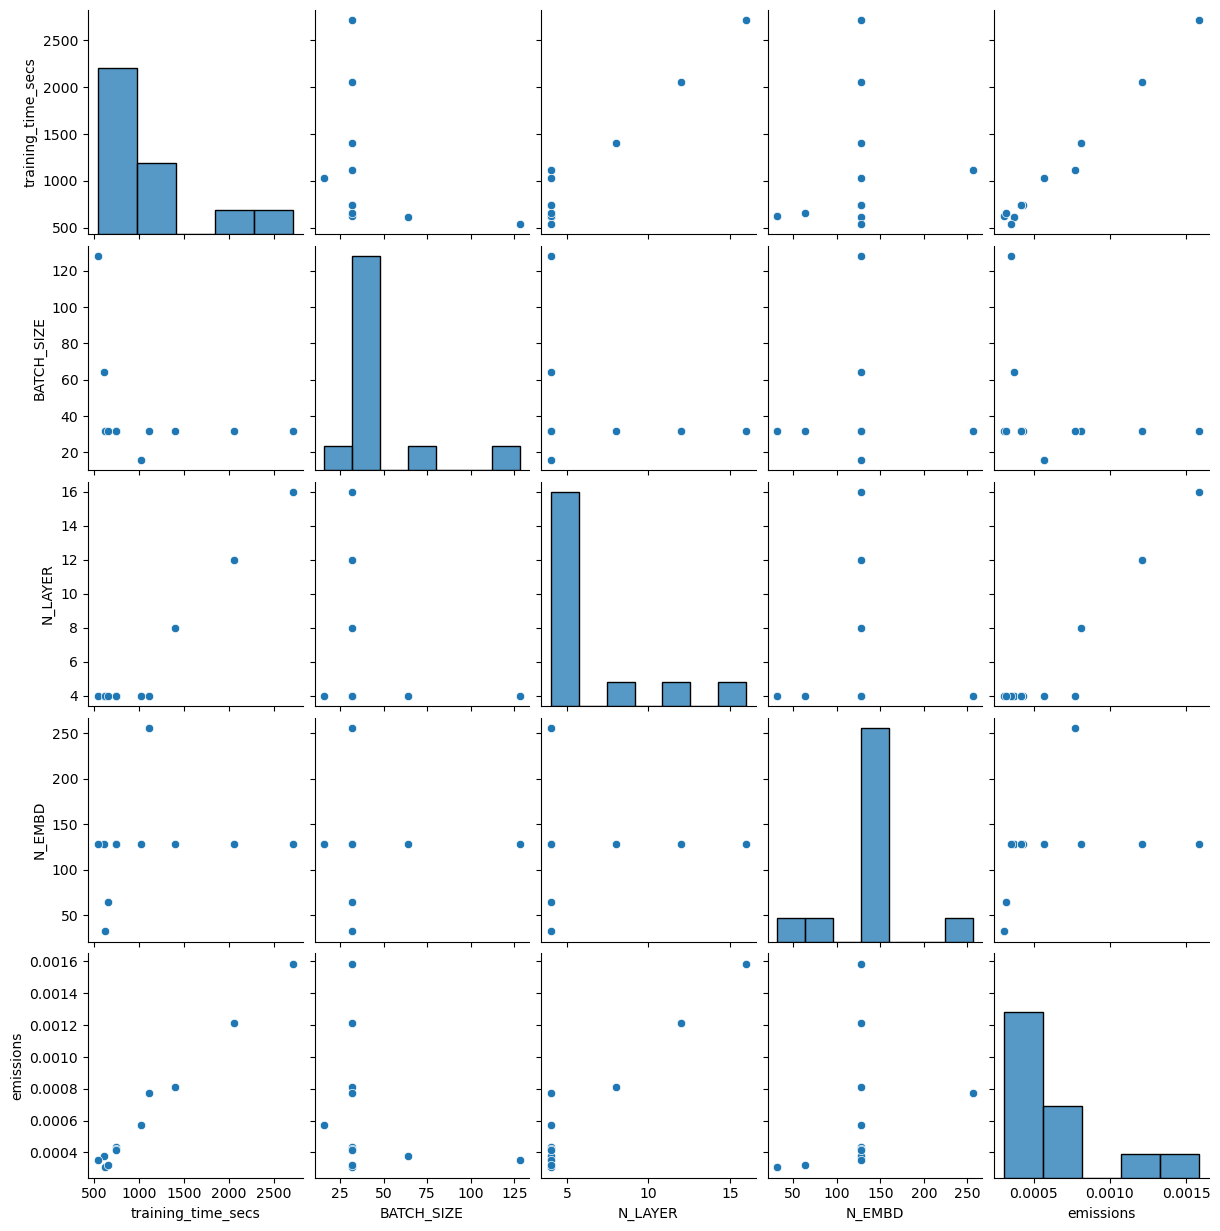

In [15]:
training_phase_data = training_phase_data_raw[["training_time_secs","BATCH_SIZE", "N_LAYER", "N_EMBD" ,"emissions"]]

sns.pairplot(data=training_phase_data)

In [16]:
lm_train = smf.ols("emissions ~ BATCH_SIZE + N_LAYER + N_EMBD", data=training_phase_data).fit()
print(lm_train.summary())

                            OLS Regression Results                            
Dep. Variable:              emissions   R-squared:                       0.990
Model:                            OLS   Adj. R-squared:                  0.986
Method:                 Least Squares   F-statistic:                     252.1
Date:                Thu, 07 May 2026   Prob (F-statistic):           2.94e-08
Time:                        10:34:12   Log-Likelihood:                 104.68
No. Observations:                  12   AIC:                            -201.4
Df Residuals:                       8   BIC:                            -199.4
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept     -0.0001   4.93e-05     -2.706      0.0

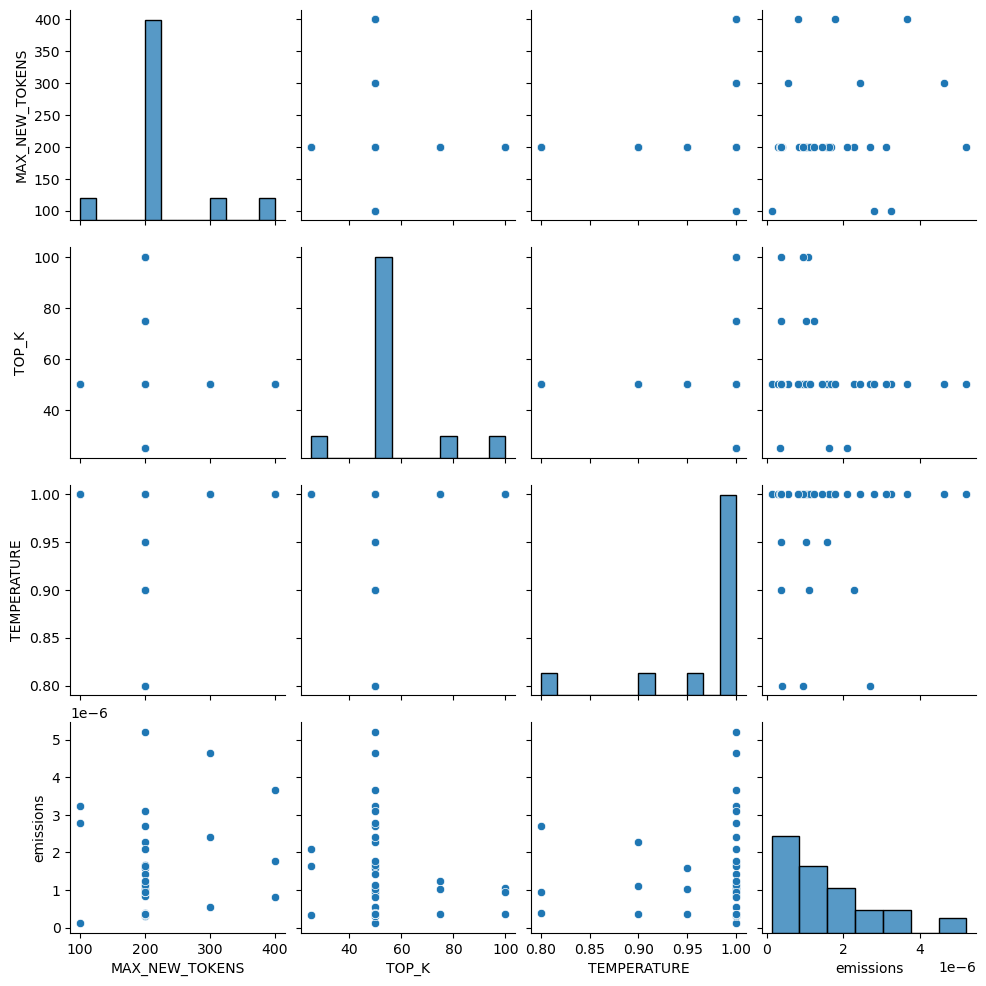

In [17]:
prompting_phase_data = prompting_phase_data_raw[["MAX_NEW_TOKENS", "TOP_K", "TEMPERATURE" ,"emissions"]]

sns.pairplot(data=prompting_phase_data)

In [18]:
lm_prompt = smf.ols("emissions ~ MAX_NEW_TOKENS + TOP_K + TEMPERATURE", data=prompting_phase_data).fit()
print(lm_prompt.summary())

                            OLS Regression Results                            
Dep. Variable:              emissions   R-squared:                       0.067
Model:                            OLS   Adj. R-squared:                 -0.021
Method:                 Least Squares   F-statistic:                    0.7631
Date:                Thu, 07 May 2026   Prob (F-statistic):              0.523
Time:                        10:34:13   Log-Likelihood:                 439.54
No. Observations:                  36   AIC:                            -871.1
Df Residuals:                      32   BIC:                            -864.8
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                     coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------
Intercept      -3.714e-07   3.51e-06     -0.